<a href="https://colab.research.google.com/github/k4urman/xternchallenge2026/blob/main/QueueSuccessRate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from sklearn.cluster import KMeans
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/GI Interactive Queue (1)(in).csv')

In [ ]:
df.head()

,Project #,Request Status,Queue Date,Withdrawn Date,Done Date,Appl In Service Date,Transmission Owner,County,State,Study Cycle,...,Summer MW,Winter MW,Fuel,Generating Facility,Post GIA Status,Negotiated In Service Date,Decision Point 1 ERIS MW,Decision Point 1 NRIS MW,Decision Point 2 ERIS MW,Decision Point 2 NRIS MW
0,J1000,Done,2018-03-12T04:00:00+00:00,NaN,2021-04-02T04:00:00+00:00,2021-10-01T04:00:00+00:00,American Transmission Co. LLC,Grant County,WI,DPP-2018-APR,...,50.0,50.0,Solar,Photovoltaic,In Service,2023-03-27T04:00:00+00:00,50.0,50.0,50.0,50.0
1,J1001,Withdrawn,2018-03-12T04:00:00+00:00,2021-03-09T05:00:00+00:00,NaN,2020-09-01T04:00:00+00:00,NORTHERN STATES POWER COMPANY,Lincoln County,MN,DPP-2018-APR,...,40.0,40.0,Solar,Photovoltaic,Not Started,NaN,40.0,40.0,0.0,0.0
2,J1002,Done,2018-03-12T04:00:00+00:00,NaN,2021-05-05T04:00:00+00:00,2021-10-01T04:00:00+00:00,American Transmission Co. LLC,Waushara County,WI,DPP-2018-APR,...,99.0,99.0,Solar,Photovoltaic,In Service,2023-01-26T05:00:00+00:00,99.0,99.0,99.0,99.0
3,J1003,Done,2018-03-12T04:00:00+00:00,NaN,2021-05-05T04:00:00+00:00,2021-10-01T04:00:00+00:00,American Transmission Co. LLC,Dodge County,WI,DPP-2018-APR,...,50.0,50.0,Solar,Photovoltaic,In Service,2023-06-06T04:00:00+00:00,50.0,50.0,50.0,50.0
4,J1004,Withdrawn,2018-03-12T04:00:00+00:00,2018-11-01T04:00:00+00:00,NaN,2020-09-01T04:00:00+00:00,METC,"Mecosta County,Montcalm County",MI,DPP-2018-APR,...,800.0,800.0,Wind,Wind Turbine,Not Started,NaN,0.0,0.0,0.0,0.0


In [ ]:
 # Q1 Can classification be used to accurately predict whether a queued project actually gets built? (Binary Logistic Classification)

In [ ]:
# Dates come in as text so they need converting before anything else

In [ ]:
# dates come in as text so they need converting
for c in ['Queue Date', 'Withdrawn Date', 'Done Date', 'Appl In Service Date']:
    df[c] = pd.to_datetime(df[c], errors='coerce')


In [ ]:

# features, done once on the whole frame
df['QUEUE_YR'] = df['Queue Date'].dt.year
df['SUMMER_MW'] = pd.to_numeric(df['Summer MW'], errors='coerce')
df['LEAD_MO'] = (df['Appl In Service Date'] - df['Queue Date']).dt.days / 30.44


In [ ]:

# label the results
df['OUTCOME'] = 'Active'
df.loc[df['Withdrawn Date'].notna(), 'OUTCOME'] = 'Withdrawn'
df.loc[df['Done Date'].notna(), 'OUTCOME'] = 'Built'


In [ ]:

df = df.dropna(subset=['SUMMER_MW', 'QUEUE_YR'])


In [ ]:

# Split
df_res = df[df['OUTCOME'] != 'Active'].copy()
df_res['BUILT'] = (df_res['OUTCOME'] == 'Built').astype(int)
df_act = df[df['OUTCOME'] == 'Active'].copy()

print('resolved:', len(df_res), ' active:', len(df_act))

resolved: 2352  active: 1464


In [ ]:
# only keep active projects targeting the 2026-2032 window, to match the load forecast
df_act = df_act[df_act['Appl In Service Date'].dt.year.between(2026, 2032)]

print('resolved:', len(df_res), ' active:', len(df_act))

resolved: 2352  active: 847


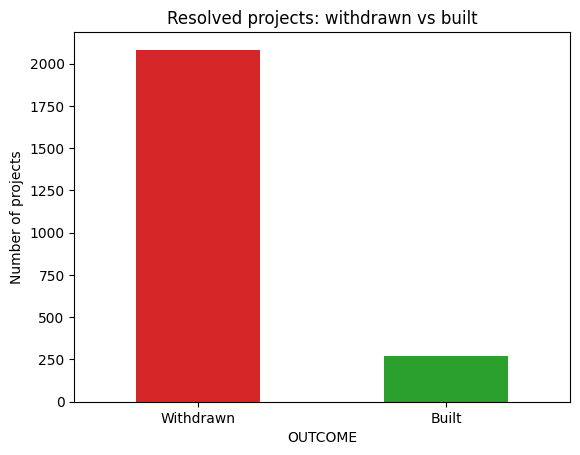

In [ ]:
# Show the split: of the projects that finished, how many got built vs withdrew
df_res['OUTCOME'].value_counts().plot(kind='bar', color=['tab:red','tab:green'])
plt.title('Resolved projects: withdrawn vs built')
plt.ylabel('Number of projects')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(df_res['OUTCOME'].value_counts(normalize=True).round(3))

OUTCOME
Withdrawn    0.886
Built        0.114
Name: proportion, dtype: float64


In [ ]:
Predictors1 = ['SUMMER_MW', 'QUEUE_YR', 'LEAD_MO', 'Fuel', 'State', 'Service Type']

In [ ]:
Combined1 = pd.get_dummies(
    pd.concat([df_res[Predictors1], df_act[Predictors1]]),
    columns=['Fuel', 'State', 'Service Type']
).fillna(0)

In [ ]:
Combined1

,SUMMER_MW,QUEUE_YR,LEAD_MO,Fuel_Battery Storage,Fuel_Biomass,Fuel_Coal,Fuel_Combined Cycle,Fuel_Diesel,Fuel_Gas,Fuel_High Voltage DC,...,State_MT,State_ND,State_SD,State_TX,State_WI,Service Type_E-NRIS,Service Type_ERIS,Service Type_NRIS,Service Type_NRIS-Only,Service Type_SIS
0,50.0,2018.0,42.674113,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
1,40.0,2018.0,29.697766,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,99.0,2018.0,42.674113,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,50.0,2018.0,42.674113,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
4,800.0,2018.0,29.697766,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3817,99.0,2026.0,46.977661,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3818,99.0,2026.0,46.977661,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3819,100.0,2026.0,19.086728,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3820,100.0,2025.0,32.128778,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
#puts all of the completed projects at the top, all of the incomplete at the bottom
X1 = Combined1.iloc[:len(df_res)]
X1_act = Combined1.iloc[len(df_res):]
Y1 = df_res['BUILT']

In [ ]:
# 80/20 train test split
X1_train, X1_test, Y1_train, Y1_test = train_test_split(
    X1, Y1, test_size=.20, random_state=42)

In [ ]:
sc = MinMaxScaler()
X1_train = pd.DataFrame(sc.fit_transform(X1_train), columns=X1.columns)
X1_test = pd.DataFrame(sc.transform(X1_test), columns=X1.columns)

In [ ]:
log = LogisticRegression(max_iter=2000, class_weight='balanced')
log.fit(X1_train, Y1_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [ ]:
Estimates1 = log.predict(X1_test)
Estimates1

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,

In [ ]:
accuracy_score(Y1_test, Estimates1)

0.7855626326963907

In [ ]:
max(Y1_test.mean(), 1 - Y1_test.mean())

np.float64(0.8789808917197452)

In [ ]:
roc_auc_score(Y1_test, log.predict_proba(X1_test)[:, 1])

np.float64(0.9040384778371048)

In [ ]:
print(classification_report(Y1_test, Estimates1,
                            target_names=['Withdrawn', 'Built']))

              precision    recall  f1-score   support

   Withdrawn       0.98      0.77      0.86       414
       Built       0.35      0.88      0.50        57

    accuracy                           0.79       471
   macro avg       0.66      0.83      0.68       471
weighted avg       0.90      0.79      0.82       471



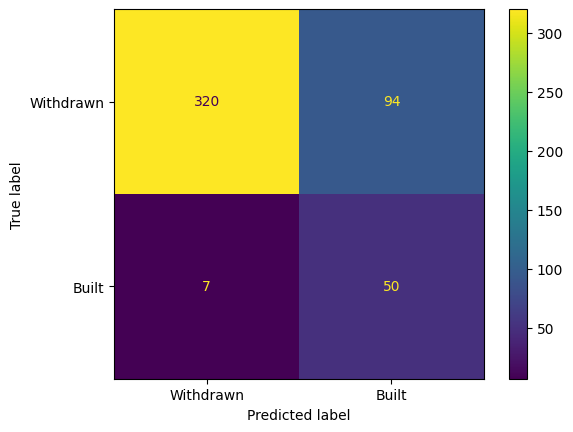

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y1_test, Estimates1,
                                        display_labels=['Withdrawn', 'Built'])
plt.show()

In [ ]:
Coefs1 = pd.Series(log.coef_[0], index=X1.columns).sort_values()
Coefs1

,0
QUEUE_YR,-8.772624
Fuel_Hybrid,-2.052958
State_ND,-1.312415
State_SD,-1.187750
Service Type_NRIS,-0.851088
Service Type_E-NRIS,-0.831179
State_MN,-0.821018
Service Type_NRIS-Only,-0.719165
State_KY,-0.675022
Fuel_Wind,-0.555812


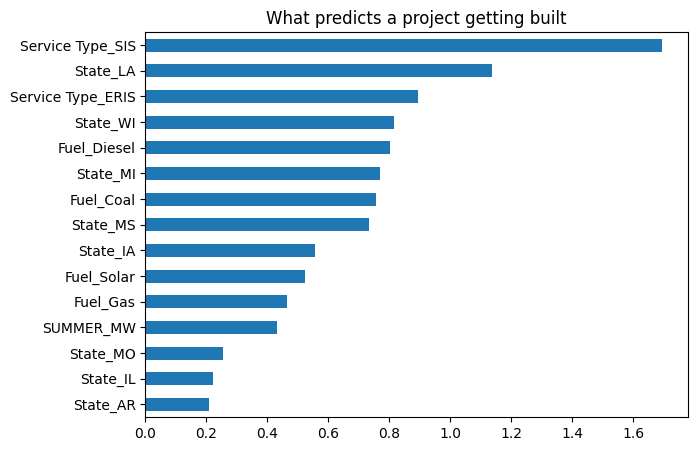

In [ ]:

Coefs1.tail(15).plot(kind='barh', figsize=(7, 5))
plt.title('What predicts a project getting built')
plt.show()


In [ ]:
#88% of resolved projects were withdrawn. The queue overstates what's coming.
#Service type predicts survival better than fuel or state.
# Labels on the bottom are how much the model weighs that category

In [ ]:
np.exp(Coefs1).round(2)

,0
QUEUE_YR,0.00
Fuel_Hybrid,0.13
State_ND,0.27
State_SD,0.30
Service Type_NRIS,0.43
Service Type_E-NRIS,0.44
State_MN,0.44
Service Type_NRIS-Only,0.49
State_KY,0.51
Fuel_Wind,0.57


In [ ]:
# scale the active projects the same way as the ones in the past (0-1)
X1_act_s = sc.transform(X1_act)

# what's the chance each active project actually gets built. answer 14%
df_act['P_BUILT'] = log.predict_proba(X1_act_s)[:, 1]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# ELCC percentages, aka: what fuel type can you count on
ELCC = {'Solar':.378,'Wind':.182,'Battery Storage':.50,
        'Hybrid':.50,'Gas':.90,'Combined Cycle':.90,'Nuclear':.95}

# Match each project to its fuel type percentage. Anything unlisted gets 50%
df_act['ELCC'] = df_act['Fuel'].map(ELCC).fillna(.50)

In [ ]:
# Megawatts to gigawatts
df_act['RAW_GW']       = df_act['SUMMER_MW'] / 1000

# Cut 1: shrink for reliability
df_act['ADJ_GW']       = df_act['RAW_GW'] * df_act['ELCC']

# Cut 2: shrink again for projects that never get built
df_act['BUILD_ADJ_GW'] = df_act['ADJ_GW'] * df_act['P_BUILT']

In [ ]:
# Add it all up by state so we can compare to how much power each state needs
state = df_act.groupby('State')[['RAW_GW','ADJ_GW','BUILD_ADJ_GW']].sum().round(2)
state.sort_values('RAW_GW', ascending=False)

,RAW_GW,ADJ_GW,BUILD_ADJ_GW
State,,,
MI,33.33,18.24,0.77
IL,31.28,12.42,0.85
AR,17.02,7.65,0.94
IN,16.10,9.36,0.20
MN,15.20,5.86,0.10
LA,12.98,6.54,1.06
IA,11.87,5.74,0.34
WI,10.95,7.51,0.50
MO,6.93,4.13,0.12
